# 01 — Phân tích dữ liệu: Criteo Uplift v2.1

Bốn câu hỏi, theo thứ tự phải trả lời xong trước khi huấn luyện model:

| # | Câu hỏi | Mục |
|---|---|---|
| 1 | Dữ liệu có đúng như hợp đồng, và cấu trúc thật của nó là gì? | [§1](#1), [§2](#2) |
| 2 | Thiết kế có cho phép suy luận nhân quả không? | [§3](#3) |
| 3 | Hiệu ứng trung bình bằng bao nhiêu, và phép đo phân giải tới đâu? | [§4](#4) |
| 4 | Có heterogeneity để mô hình hoá không, và nó có **dạng** gì? | [§5](#5) |

Câu 4 là câu quyết định hướng đi của dự án. Trả lời nó bằng dữ liệu thô, không qua model nào,
đã đủ để đoán trước kết quả mà ba sprint sau đó xác nhận: một model dự báo outcome xếp hạng
khách hàng ngang hoặc hơn mọi CATE learner đã thử.

Notebook tính lại mọi số từ file gốc 13.979.592 dòng bằng [`src/eda.py`](../src/eda.py), rồi
đối chiếu với artifact đóng băng ở [`output/eda/`](../output/eda/) do
[`scripts/run_eda_profile.py`](../scripts/run_eda_profile.py) sinh ra. Phép đối chiếu ở
[§1.1](#0.2).

Notebook tiếp theo: [`02_modeling_and_evaluation.ipynb`](02_modeling_and_evaluation.ipynb).

<a id="0.1"></a>
## 0.1 Thiết lập

In [1]:
import sys, pathlib, json, time

sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

from src.paths import CRITEO_PATH, OUTPUT_DIR
from src.data import FEATURES, load_criteo_full, propensity_auc, stratified_sample, validate_criteo_schema
from src.eda import (
    arm_outcome_table, balance_table, binned_effect_table, cochran_q,
    difference_in_means, duplicate_profile, feature_cardinality_profile, file_sha256,
    minimum_detectable_effect, post_treatment_leakage_report, prognostic_dominance_summary,
    propensity_overlap, quantile_bins, required_sample_size, sample_representativity,
    sentinel_mask_agreement, sentinel_mask_matrix, sentinel_mask_profile,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# --- Bang mau: dung chung voi notebook 02 de hai notebook doc lien mach. ---
# Da chay qua validator cua skill dataviz: lightness band, chroma floor,
# CVD separation va normal-vision floor deu PASS tren surface #fcfcfb.
TREATMENT = "#2a78d6"   # nhanh treatment
CONTROL   = "#eb6834"   # nhanh control
ACCENT    = "#4a3aa7"   # duong tham chieu / gia tri suy ra
MUTED     = "#898781"   # muc khong mang danh tinh
REF       = "#c3c2b7"   # luoi, nguong, duong phu
INK, INK2 = "#0b0b0b", "#52514e"
BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
             "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.edgecolor": REF,
    "axes.labelcolor": INK2,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.7,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.titlesize": 11.5,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9.5,
})

EDA_DIR = OUTPUT_DIR / "eda"
frozen = json.loads((EDA_DIR / "run_manifest.json").read_text(encoding="utf-8"))
print("Artifact da dong bang:", EDA_DIR.relative_to(EDA_DIR.parent.parent).as_posix())
print("Run truoc do:", frozen["run"]["elapsed_seconds"], "giay ·",
      len(frozen["artifacts"]), "file · seed", frozen["run"]["seed"])

Artifact da dong bang: output/eda
Run truoc do: 145.7 giay · 17 file · seed 42


<a id="1"></a>
## 1. Xuất xứ và hợp đồng dữ liệu

Mọi so sánh model của dự án dùng chung một holdout. File nguồn lệch một dòng thì số vẫn chạy
ra, nhưng hết so được với các sprint trước. Nên mỗi lần chạy đều assert SHA-256 và data
contract trước tiên.

Contract kiểm bốn điều: đủ 16 cột, bốn cột nhị phân chỉ chứa `{0, 1}`, không ô thiếu, mọi giá
trị `f0`–`f11` hữu hạn.

In [2]:
t0 = time.time()
checksum = file_sha256(CRITEO_PATH)
EXPECTED_SHA256 = "2716e1bf0fd157a93b5bf86924d9088419dfbac2022c6cd90030220634f616dc"
assert checksum == EXPECTED_SHA256, f"File nguon khac voi ban da dang ky: {checksum}"

df = load_criteo_full(dtype_f32=True)
contract = validate_criteo_schema(df)
assert contract["valid"], contract
assert df.shape == (13_979_592, 16)

n_rows = len(df)
print(f"sha256          : {checksum[:16]}... (khop ban dang ky)")
print(f"kich thuoc file : {CRITEO_PATH.stat().st_size:,} byte")
print(f"shape           : {df.shape[0]:,} dong x {df.shape[1]} cot")
print(f"o thieu         : {contract['missing_cells']}")
print(f"cot nhi phan    : {', '.join(f'{k}={v}' for k, v in contract['binary_values'].items())}")
print(f"nap trong       : {time.time() - t0:.1f}s")
df.head(3)

sha256          : 2716e1bf0fd157a9... (khop ban dang ky)
kich thuoc file : 311,422,618 byte
shape           : 13,979,592 dong x 16 cot
o thieu         : 0
cot nhi phan    : treatment=[0, 1], conversion=[0, 1], visit=[0, 1], exposure=[0, 1]
nap trong       : 42.9s


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616364,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616364,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616364,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


Năm dòng đầu gần như trùng nhau, chỉ khác ở `f2`. [§2.4](#2.4) đo mức trùng lặp đó bằng số.

<a id="0.2"></a>
### 1.1 Đối chiếu với artifact đã đóng băng

Notebook và `run_eda_profile.py` cùng tính từ dữ liệu thô, khác tiến trình và thời điểm. Hai
bên phải ra cùng số. Phép kiểm đặt ở đầu: fail thì mọi diễn giải phía sau đều đáng ngờ.

In [3]:
summary_frozen = pd.read_csv(EDA_DIR / "eda_summary.csv").set_index("metric")["value"]

live = {
    "n_rows": float(n_rows),
    "treatment_rate": float(df["treatment"].mean()),
    "conversion_rate": float(df["conversion"].mean()),
    "conversion_events_control": float(df.loc[df["treatment"] == 0, "conversion"].sum()),
    "n_missing_cells": float(contract["missing_cells"]),
}
check = pd.DataFrame({
    "notebook (tinh lai)": pd.Series(live),
    "output/eda (dong bang)": summary_frozen.reindex(live).astype(float),
})
check["khop"] = np.isclose(check.iloc[:, 0], check.iloc[:, 1], rtol=1e-9)
assert check["khop"].all(), check
assert frozen["source"]["sha256"] == checksum, "Artifact duoc sinh tu mot file nguon khac"
display(check)
print("Notebook va artifact dong bang khop tren moi chi so kiem tra.")

,notebook (tinh lai),output/eda (dong bang),khop
n_rows,1.397959e+07,1.397959e+07,True
treatment_rate,8.500001e-01,8.500001e-01,True
conversion_rate,2.916680e-03,2.916680e-03,True
conversion_events_control,4.063000e+03,4.063000e+03,True
n_missing_cells,0.000000e+00,0.000000e+00,True


Notebook va artifact dong bang khop tren moi chi so kiem tra.


<a id="2"></a>
## 2. Cấu trúc biến — điều mà "0 ô thiếu" không nói ra

Contract báo **0 ô thiếu**. Đúng về cú pháp, gần như vô nghĩa về thống kê.

`f0`–`f11` đã được ẩn danh và chiếu ngẫu nhiên trước khi phát hành
([data card](../docs/data_cards/CRITEO_V2_1.md)), nên mục này nói về hình dạng phân phối,
không nói về ý nghĩa biến.

<a id="2.1"></a>
### 2.1 Cardinality và khối lượng tập trung ở mode

Ba cột cần đọc kỹ:

- `mode_share` — tỉ lệ dòng nằm đúng ở giá trị mode.
- `n_effective_quantile_bins` — số bin thật sự tạo được khi cắt 10 phân vị. Bằng 1 là không
  phân tầng được theo phân vị.
- `kurtosis` — cho biết quy tắc outlier dạng `±k·sigma` có dùng được không.

In [4]:
cardinality = feature_cardinality_profile(df, FEATURES, n_quantile_bins=10)
show = cardinality[["feature", "n_unique", "mode_value", "mode_share", "top3_share",
                    "skew", "kurtosis", "n_effective_quantile_bins"]]
display(
    show.style
        .format({"mode_value": "{:.4f}", "mode_share": "{:.3f}", "top3_share": "{:.3f}",
                 "skew": "{:.2f}", "kurtosis": "{:.1f}", "n_unique": "{:,}"})
        .background_gradient(subset=["mode_share"], cmap="Oranges", vmin=0, vmax=1)
        .hide(axis="index")
)

n_degenerate = int((cardinality["n_effective_quantile_bins"] < 2).sum())
print(f"\n{n_degenerate}/12 feature khong tao duoc du hai bin phan vi.")
print(f"mode_share cao nhat: {cardinality['mode_share'].max():.4f} "
      f"({cardinality.loc[cardinality['mode_share'].idxmax(), 'feature']})")

feature,n_unique,mode_value,mode_share,top3_share,skew,kurtosis,n_effective_quantile_bins
f0,"2,181,959",12.6164,0.265,0.265,-0.25,-1.6,8
f1,60,10.0597,0.988,0.998,14.00,267.6,1
f2,"808,663",8.2144,0.522,0.522,0.81,-1.0,5
f3,552,4.6799,0.819,0.882,-3.19,10.5,2
f4,260,10.2805,0.957,0.989,8.88,104.1,1
f5,132,4.1155,0.947,0.991,-7.09,68.8,1
f6,"1,645",0.2944,0.265,0.512,-1.14,0.8,7
f7,"622,143",4.8338,0.947,0.947,4.52,19.2,1
f8,"3,743",3.9719,0.522,0.650,-1.61,1.9,5
f9,"1,594",13.1901,0.795,0.852,2.82,7.7,3



6/12 feature khong tao duoc du hai bin phan vi.
mode_share cao nhat: 0.9877 (f1)


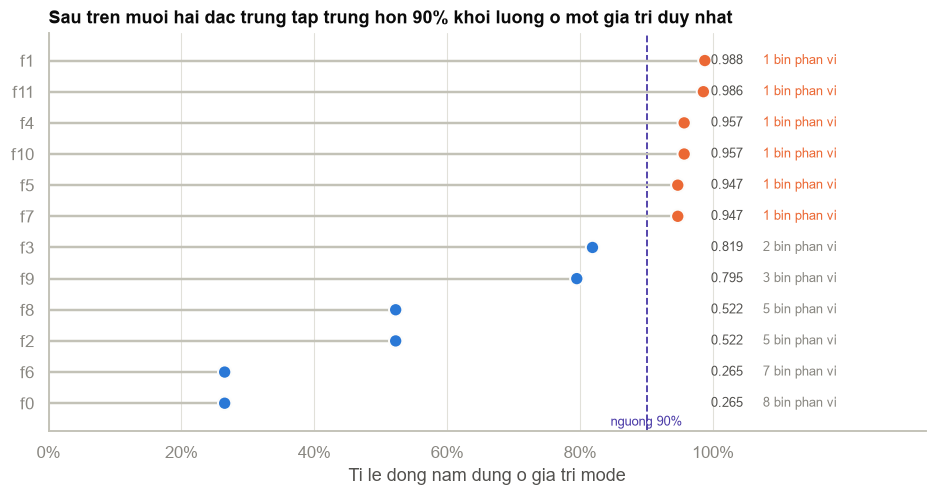

In [5]:
order = cardinality.sort_values("mode_share")
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.hlines(y, 0, order["mode_share"], color=REF, lw=1.6, zorder=1)
colors = [CONTROL if s > 0.9 else TREATMENT for s in order["mode_share"]]
ax.scatter(order["mode_share"], y, s=76, c=colors, zorder=3,
           edgecolor="#fcfcfb", linewidth=1.3)
ax.axvline(0.9, color=ACCENT, ls="--", lw=1.2, zorder=0)

# Nhan xep thanh mot cot o le phai, khong bam theo diem, de khong dam vao nguong 0,9.
for i, (share, bins) in enumerate(zip(order["mode_share"], order["n_effective_quantile_bins"])):
    ax.annotate(f"{share:.3f}", (1.045, i), va="center", ha="right", fontsize=8.5, color=INK2)
    ax.annotate(f"{bins} bin phan vi", (1.075, i), va="center", ha="left", fontsize=8.5,
                color=CONTROL if bins < 2 else MUTED)

ax.set_yticks(y, order["feature"])
ax.set_ylim(-0.9, len(order) - 0.1)
ax.set_xlim(0, 1.32)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.annotate("nguong 90%", (0.9, -0.72), ha="center", fontsize=8.5, color=ACCENT)
ax.set_xlabel("Ti le dong nam dung o gia tri mode")
ax.set_title("Sau tren muoi hai dac trung tap trung hon 90% khoi luong o mot gia tri duy nhat")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

`f1` và `f11` có gần 99% số dòng ở đúng một giá trị; `f4`, `f5`, `f7`, `f10` trên 94%. Sáu
đặc trưng đó không cắt nổi thành hai nhóm phân vị.

Ba cách mô tả quen thuộc thành sai ở đây:

- `mean`/`std` gợi ý biến liên tục, thực tế là một điểm khối lượng cộng đuôi mỏng. `kurtosis`
  của `f11` bằng 294.
- Đếm outlier bằng `±5·sigma` giả định phân phối gần chuẩn. `skew` của `f11` bằng `−14,8`.
- "12 đặc trưng" gợi ý không gian 12 chiều. [§2.3](#2.3) cho con số thật.

<a id="2.2"></a>
### 2.2 Point mass là sentinel value, không phải một mức thật

Khối lượng dồn vào đúng một giá trị hiếm khi là một mức có thật của biến. Khả năng cao hơn:
đó là **sentinel value**, mã mà pipeline gốc dùng cho *không quan sát được*.

Kiểm được. Hai đặc trưng dùng chung một nguồn missingness thì tập dòng nằm ở sentinel của
chúng phải **trùng khít**, dù giá trị sentinel khác nhau. Ma trận dưới đo tỉ lệ dòng mà hai
đặc trưng cùng ở, hoặc cùng không ở, sentinel.

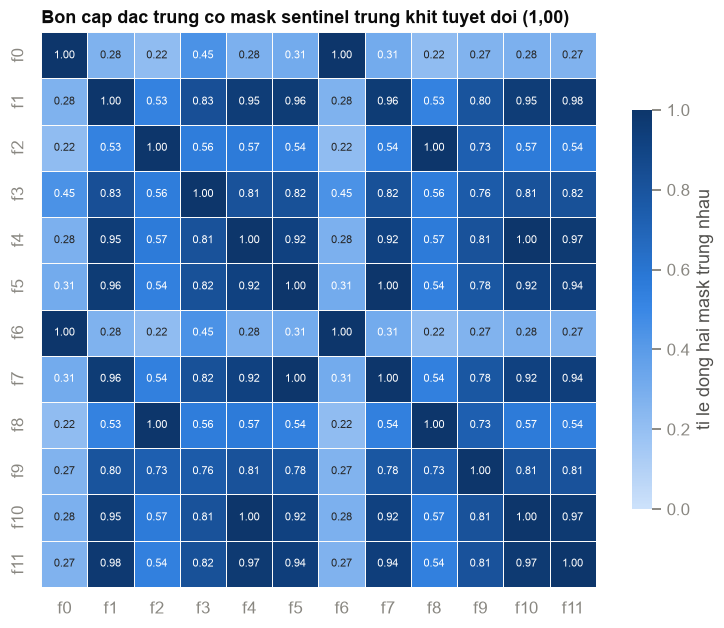

Cap dung chung nguon missingness: (f0, f6), (f2, f8), (f4, f10), (f5, f7)

Sentinel value:


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
sentinel_value,12.6164,10.0597,8.2144,4.6799,10.2805,4.1155,0.2944,4.8338,3.9719,13.1901,5.3004,-0.1687


In [6]:
mask, sentinels = sentinel_mask_matrix(df, FEATURES)
agreement = sentinel_mask_agreement(mask)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
sns.heatmap(agreement, annot=True, fmt=".2f", annot_kws={"size": 7.5},
            cmap=sns.blend_palette(BLUE_RAMP, as_cmap=True), vmin=0, vmax=1,
            square=True, linewidths=0.6, linecolor="#fcfcfb",
            cbar_kws={"label": "ti le dong hai mask trung nhau", "shrink": 0.72}, ax=ax)
ax.set_title("Bon cap dac trung co mask sentinel trung khit tuyet doi (1,00)")
plt.tight_layout()
plt.show()

shared = [(a, b) for i, a in enumerate(FEATURES) for b in FEATURES[i + 1:]
          if agreement.loc[a, b] == 1.0]
print("Cap dung chung nguon missingness:", ", ".join(f"({a}, {b})" for a, b in shared))
print("\nSentinel value:")
display(pd.Series(sentinels, name="sentinel_value").to_frame().T.style.format("{:.4f}"))

**Bốn cặp trùng khít ở đúng `1,00`:** `(f0, f6)`, `(f2, f8)`, `(f4, f10)`, `(f5, f7)`. Trên
13,98 triệu dòng, ngẫu nhiên không cho ra chuyện đó.

Vậy 12 đặc trưng không mang 12 nguồn quan sát độc lập. Mỗi nguồn khi vắng mặt kéo theo cả hai
đặc trưng của nó vắng mặt.

Phạm vi: đây là suy luận từ cấu trúc quan sát được.
[Data card](../docs/data_cards/CRITEO_V2_1.md) không xác nhận, và Criteo không công bố quy
trình mã hoá giá trị thiếu. Dùng nó để **giải thích**, đừng dùng để hoàn nguyên giá trị gốc.

<a id="2.3"></a>
### 2.3 Chiều thông tin thực tế của mỗi dòng

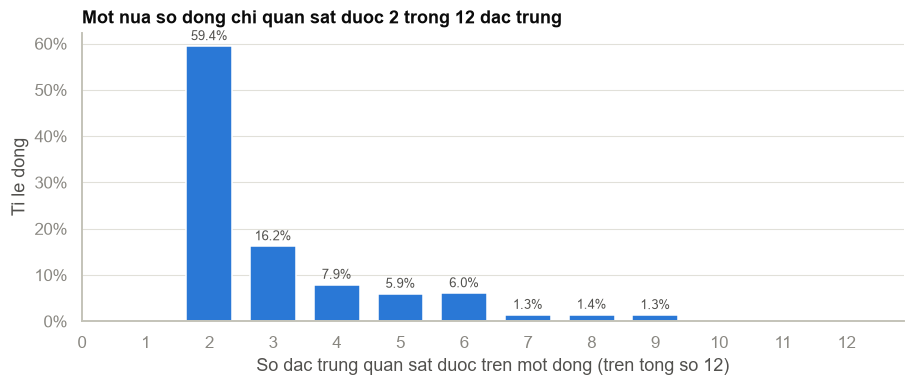

So pattern sentinel khac nhau : 53 (toi da co the co: 4096)
Trung vi so dac trung quan sat: 2/12

O = quan sát được (khác sentinel), . = ở sentinel value


pattern,pattern_key,n_rows,share
O.....O.....,4030,"6,095,535",0.4360
..O.....O...,3835,"2,193,352",0.1569
..O.....OO..,3323,"1,295,853",0.0927
O..O..O.....,4022,"962,465",0.0688
O.O...O.O...,3770,"860,300",0.0615
O.OO..O.OO..,3250,"605,518",0.0433
O.OO..O.O...,3762,"393,099",0.0281
O.O...O.OO..,3258,"338,265",0.0242


In [7]:
pattern = sentinel_mask_profile(mask, top_k=8)
observed = pattern["observed_per_row"]

fig, ax = plt.subplots(figsize=(8.4, 3.6))
bars = ax.bar(observed.index, observed["share"], color=TREATMENT, width=0.72, zorder=2)
for value, share in zip(observed.index, observed["share"]):
    if share >= 0.01:
        ax.annotate(f"{share:.1%}", (value, share), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8.5, color=INK2)
ax.set_xlabel("So dac trung quan sat duoc tren mot dong (tren tong so 12)")
ax.set_ylabel("Ti le dong")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(range(0, 13))
ax.set_title("Mot nua so dong chi quan sat duoc 2 trong 12 dac trung")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(f"So pattern sentinel khac nhau : {pattern['n_distinct_patterns']} "
      f"(toi da co the co: {pattern['n_possible_patterns']})")
print(f"Trung vi so dac trung quan sat: {pattern['median_observed_features']:.0f}/12")
print(f"\n{pattern['legend']}")
display(pattern["top_patterns"].style.format({"share": "{:.4f}", "n_rows": "{:,}"}).hide(axis="index"))

53 pattern trên 4.096 khả năng; pattern phổ biến nhất một mình chiếm 43,6% số dòng; trung vị
**2 trên 12** đặc trưng quan sát được mỗi dòng. Đây là ràng buộc cấu trúc lớn nhất của bộ dữ
liệu.

Với phần lớn dân số, covariate gần như không có biến thiên để phân biệt người này với người
kia. Estimator tinh vi đến đâu cũng không tạo ra được thông tin mà dữ liệu không chứa.

Heterogeneity vẫn tồn tại và rất lớn ([§5](#5)). Nó nằm ở *pattern quan sát được*, không nằm
ở giá trị liên tục của đặc trưng — hai bài toán khác nhau về độ khó.

<a id="2.4"></a>
### 2.4 Trùng lặp vector đặc trưng

In [8]:
duplicates = duplicate_profile(df, FEATURES)
display(pd.Series(duplicates, name="gia tri").to_frame().style.format({
    "gia tri": lambda v: f"{v:,.4f}" if isinstance(v, float) else f"{v:,}"}))

,gia tri
n_rows,"13,979,592.0000"
n_distinct_feature_vectors,"11,859,441.0000"
n_duplicate_rows,"2,120,151.0000"
duplicate_row_share,0.1517
n_rows_in_repeated_groups,"3,560,505.0000"
share_rows_in_repeated_groups,0.2547
max_group_size,24.0000
mean_group_size,1.1788


15,2% số dòng có vector `f0`–`f11` trùng dòng khác; 25,5% nằm trong một nhóm trùng lặp; nhóm
lớn nhất 24 dòng.

Hai hệ quả ngược chiều nhau:

- **Có lợi:** tồn tại những tầng `X` trùng khít, nên so treatment/control bên trong cùng một
  giá trị covariate là làm được, không cần model nào.
- **Có hại:** các dòng không hoàn toàn độc lập, trong khi bootstrap của dự án lấy mẫu ở mức
  dòng. Ở tỉ lệ này ảnh hưởng lên độ rộng CI là nhỏ; để số ở đây cho người đọc tự đánh giá.

<a id="2.5"></a>
### 2.5 Tương quan giữa các đặc trưng

Pearson đo quan hệ tuyến tính và bị point mass kéo mạnh; Spearman đo quan hệ đơn điệu, bền
hơn trước phân phối lệch. Với dữ liệu như ở [§2.1](#2.1), một mình Pearson cho ấn tượng sai.

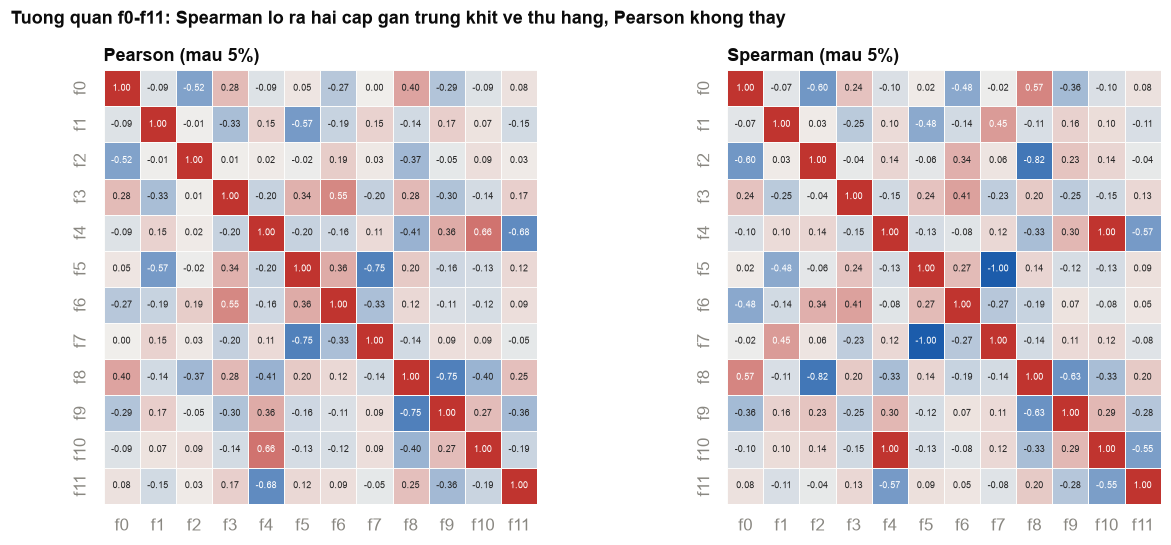

,|spearman|,|pearson|,cung sentinel
f10 - f4,0.9992,0.6596,True
f5 - f7,0.9989,0.7454,True
f2 - f8,0.8196,0.3735,True
f8 - f9,0.6275,0.7501,False
f2 - f0,0.5958,0.5167,False
f11 - f4,0.5742,0.6776,False


Cap co |Spearman| > 0,99 — gan trung khit ve thu hang:


  f4 - f10: rho = +0.9992, |Pearson| = 0.6596, so gia tri phan biet 260 vs 483,634


  f5 - f7: rho = -0.9989, |Pearson| = 0.7454, so gia tri phan biet 132 vs 622,143


In [9]:
sample_5pct = stratified_sample(df, frac=0.05, seed=42)
pearson = sample_5pct[FEATURES].corr(method="pearson")
spearman = sample_5pct[FEATURES].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(11.6, 5.0))
diverging = sns.blend_palette(["#1c5cab", "#f0efec", "#c0342f"], as_cmap=True)
for ax, matrix, name in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    sns.heatmap(matrix, annot=True, fmt=".2f", annot_kws={"size": 6.2}, cmap=diverging,
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
                linecolor="#fcfcfb", cbar=False, ax=ax)
    ax.set_title(f"{name} (mau 5%)")
fig.suptitle("Tuong quan f0-f11: Spearman lo ra hai cap gan trung khit ve thu hang, Pearson khong thay",
             x=0.02, ha="left", fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.show()

off_diagonal = ~np.eye(len(FEATURES), dtype=bool)
pairs = (spearman.where(off_diagonal).abs().stack()
         .sort_values(ascending=False).iloc[::2].head(6).rename("|spearman|").to_frame())
pairs["|pearson|"] = [abs(pearson.loc[a, b]) for a, b in pairs.index]
pairs["cung sentinel"] = [agreement.loc[a, b] == 1.0 for a, b in pairs.index]
pairs.index = [f"{a} - {b}" for a, b in pairs.index]
display(pairs.style.format({"|spearman|": "{:.4f}", "|pearson|": "{:.4f}"}))

print("Cap co |Spearman| > 0,99 — gan trung khit ve thu hang:")
for i, a in enumerate(FEATURES):
    for b in FEATURES[i + 1:]:
        if abs(spearman.loc[a, b]) <= 0.99:
            continue
        n_a, n_b = df[a].nunique(), df[b].nunique()
        print(f"  {a} - {b}: rho = {spearman.loc[a, b]:+.4f}, "
              f"|Pearson| = {abs(pearson.loc[a, b]):.4f}, "
              f"so gia tri phan biet {n_a:,} vs {n_b:,}")

Pearson cho `f4`–`f10` bằng `0,66`, `f5`–`f7` bằng `−0,75`: tương quan mạnh, không đáng lo.
Spearman cho cùng hai cặp đó **`+0,999` và `−0,999`**.

Hai cặp này gần trùng khít về thứ hạng. Chúng không trùng chính xác: `f4` có 260 giá trị,
`f10` có 483.634, tức `f10` là phiên bản mịn hơn của cùng một đại lượng. Nhưng phần thông tin
xếp hạng riêng của biến thứ hai rất nhỏ, và Pearson không thấy vì quan hệ giữa chúng phi
tuyến. Đây là lý do cụ thể để báo cả hai thước đo.

Cộng với [§2.2](#2.2): `(f4, f10)` và `(f5, f7)` vừa dùng chung sentinel vừa gần trùng về thứ
hạng, và cả bốn nằm trong nhóm sáu đặc trưng **không** phân tầng được ở [§5.1](#5.1).
`(f0, f6)` và `(f2, f8)` dùng chung sentinel nhưng thứ hạng khác hẳn nhau — chia sẻ *cơ chế
quan sát*, không chia sẻ *nội dung* — và đúng bốn đặc trưng đó phân tầng được.

Đa cộng tuyến không phải vấn đề với model dạng cây. Vấn đề là **chiều thông tin hiệu dụng**.

<a id="3"></a>
## 3. Thiết kế thí nghiệm có cho phép suy luận nhân quả không

Cả khung đánh giá phía sau dựa trên một tính chất: treatment gán ngẫu nhiên, độc lập với đặc
trưng. Tính chất đó hỏng thì hiệu hai tỉ lệ hết là ước lượng không thiên lệch của ATE.

**Giới hạn phải đọc trước khi xem số.** Các chẩn đoán dưới đây đo *cân bằng quan sát được*.
Cân bằng là hệ quả của randomization, không phải bằng chứng của nó; căn cứ thật đến từ
provenance — Criteo công bố đây là một randomized incrementality test. Chúng có vai trò phát
hiện hỏng hóc: fail thì có vấn đề, pass thì chỉ là không tìm thấy vấn đề.

<a id="3.1"></a>
### 3.1 Kích thước hai nhánh và số sự kiện tuyệt đối

In [10]:
arms = arm_outcome_table(df, ["conversion", "visit", "exposure"])
pivot = arms.pivot(index="outcome", columns="treatment", values=["n_events", "rate"])
pivot.columns = [f"{a}_{'control' if b == 0 else 'treated'}" for a, b in pivot.columns]
pivot = pivot.loc[["conversion", "visit", "exposure"]]
display(pivot.style.format({
    "n_events_control": "{:,.0f}", "n_events_treated": "{:,.0f}",
    "rate_control": "{:.6f}", "rate_treated": "{:.6f}"}))

n_treated = int((df["treatment"] == 1).sum())
n_control = n_rows - n_treated
print(f"treated : {n_treated:,} dong ({n_treated / n_rows:.4f})")
print(f"control : {n_control:,} dong ({n_control / n_rows:.4f})")
print(f"\nSo conversion o nhanh control: {int(pivot.loc['conversion', 'n_events_control']):,}")

,n_events_control,n_events_treated,rate_control,rate_treated
outcome,,,,
conversion,"4,063","36,711",0.001938,0.003089
visit,"80,105","576,824",0.038201,0.048543
exposure,0,"428,212",0.000000,0.036037


treated : 11,882,655 dong (0.8500)
control : 2,096,937 dong (0.1500)

So conversion o nhanh control: 4,063


Ba con số định hình mọi thứ về sau.

**Tỉ lệ gán 85/15.** Nhánh control, nguồn thông tin phản thực duy nhất, chỉ có 15% dữ liệu.
Đây là lý do propensity được cố định `0,85` trong
[protocol](../configs/sprint3_improvement_protocol.json) thay vì đi ước lượng: RCT thì `e(x)`
biết chính xác, nên vế IPW của tín hiệu doubly robust luôn đúng.

**Conversion rate 0,29%.** Bài toán sự kiện hiếm.

**Control chỉ có 4.063 conversion.** Đây mới là mẫu số thật của mọi ước lượng phản thực, và
là trần thông tin của cả dự án. [§4.2](#4.2) quy nó ra giới hạn phân giải cụ thể.

<a id="3.2"></a>
### 3.2 Cân bằng covariate — SMD và Love plot

SMD là tiêu chí chính vì nó là **effect size**, không đổi khi cỡ mẫu tăng. Với 14 triệu dòng,
p-value của bất kỳ kiểm định nào cũng nhỏ khi chênh lệch thật chỉ bằng 0,001 độ lệch chuẩn.

Ngưỡng quy ước trong tài liệu matching: `|SMD| < 0,1`.

In [11]:
balance = balance_table(sample_5pct, FEATURES)
display(balance.style.format({
    "mean_treatment": "{:.4f}", "mean_control": "{:.4f}", "mean_difference": "{:.5f}",
    "pooled_sd": "{:.4f}", "smd": "{:+.4f}", "abs_smd": "{:.4f}",
    "ks_stat": "{:.5f}", "ks_p_value": "{:.2e}"}).hide(axis="index"))
print(f"|SMD| lon nhat: {balance['abs_smd'].max():.4f} ({balance.iloc[0]['feature']})")
print(f"So feature vuot nguong 0,1: {(balance['abs_smd'] > 0.1).sum()}/12")

feature,mean_treatment,mean_control,mean_difference,pooled_sd,smd,abs_smd,ks_stat,ks_p_value
f3,4.1715,4.2351,-0.06356,1.2963,-0.0490,0.0490,0.01378,3.95e-15
f6,-4.1780,-3.9917,-0.18630,4.5236,-0.0412,0.0412,0.01457,7.19e-17
f5,4.0264,4.0394,-0.01297,0.4145,-0.0313,0.0313,0.00515,1.76e-02
f1,10.0703,10.0681,0.00220,0.0998,+0.0221,0.0221,0.00223,7.66e-01
f9,16.0384,15.9091,0.12923,6.9394,+0.0186,0.0186,0.00555,8.30e-03
f8,3.9335,3.9345,-0.00100,0.0561,-0.0178,0.0178,0.00651,1.04e-03
f7,5.1048,5.0838,0.02096,1.1914,+0.0176,0.0176,0.00515,1.76e-02
f10,5.3334,5.3317,0.00171,0.1661,+0.0103,0.0103,0.00247,6.49e-01
f4,10.3388,10.3354,0.00345,0.3375,+0.0102,0.0102,0.00218,7.91e-01
f11,-0.1710,-0.1708,-0.00012,0.0227,-0.0055,0.0055,0.00101,1.00e+00


|SMD| lon nhat: 0.0490 (f3)
So feature vuot nguong 0,1: 0/12


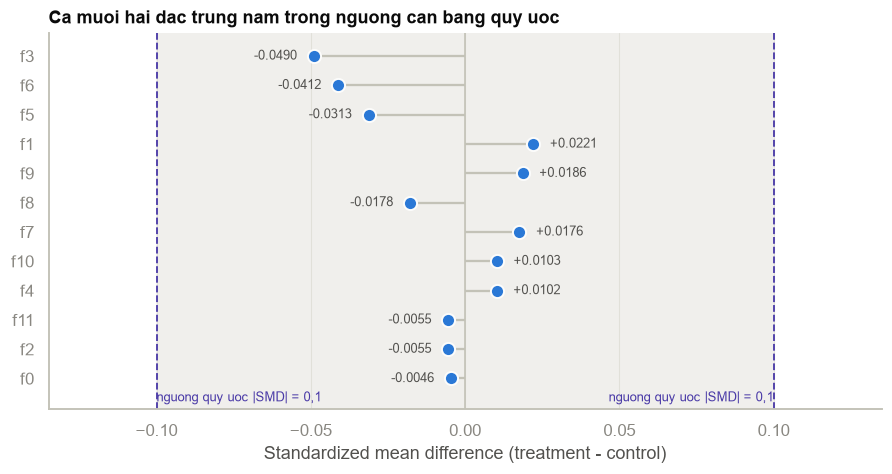

In [12]:
love = balance.sort_values("abs_smd")
y = np.arange(len(love))

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.axvspan(-0.1, 0.1, color="#f0efec", zorder=0)
ax.axvline(0, color=REF, lw=1.1, zorder=1)
for threshold in (-0.1, 0.1):
    ax.axvline(threshold, color=ACCENT, ls="--", lw=1.2, zorder=1)
ax.hlines(y, 0, love["smd"], color=REF, lw=1.5, zorder=2)
ax.scatter(love["smd"], y, s=74, color=TREATMENT, zorder=3,
           edgecolor="#fcfcfb", linewidth=1.3)
for i, value in enumerate(love["smd"]):
    ax.annotate(f"{value:+.4f}", (value, i),
                xytext=(11 if value >= 0 else -11, 0), textcoords="offset points",
                va="center", ha="left" if value >= 0 else "right",
                fontsize=8.3, color=INK2)
for threshold, align in ((-0.1, "left"), (0.1, "right")):
    ax.annotate("nguong quy uoc |SMD| = 0,1", (threshold, -0.78), ha=align,
                fontsize=8.5, color=ACCENT)
ax.set_yticks(y, love["feature"])
ax.set_ylim(-1.05, len(love) - 0.2)
ax.set_xlim(-0.135, 0.135)
ax.set_xlabel("Standardized mean difference (treatment - control)")
ax.set_title("Ca muoi hai dac trung nam trong nguong can bang quy uoc")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

`|SMD|` lớn nhất là **0,049** ở `f3`, bằng nửa ngưỡng. Không đặc trưng nào vượt `0,1`.

Cũng `f3` đó có `ks_p_value ≈ 4e-15`, tức "khác biệt có ý nghĩa thống kê" theo mọi ngưỡng.
Hai kết luận trái ngược trên cùng một đặc trưng, và cả hai đều đúng: với `N ≈ 700K` mỗi nhóm,
KS-test bắt được chênh lệch nhỏ tới mức không có ý nghĩa thực tế. **Đó là lý do tiêu chí
chính là effect size.**

<a id="3.3"></a>
### 3.3 Propensity và overlap

Hai chẩn đoán bổ sung cho SMD.

**Propensity AUC.** Fit model dự đoán `treatment` từ `f0`–`f11`; gán ngẫu nhiên thì không
model nào hơn tung đồng xu. Notebook chạy **hai** model. Model cây cần thiết vì [§2.2](#2.2)
cho thấy cấu trúc nằm ở pattern sentinel, thứ mà logistic regression gần như không đọc được;
chỉ chạy model tuyến tính là bằng chứng yếu.

**Overlap (positivity).** IPW/DR chỉ xác định được khi `0 < e(x) < 1`. RCT thì đúng theo
thiết kế, nhưng vẫn phải kiểm: một lỗi ở khâu lọc dòng sẽ hiện ra thành vùng chỉ có một arm.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    auc_linear = propensity_auc(sample_5pct, FEATURES, seed=42)

train_df, test_df = train_test_split(sample_5pct, test_size=0.3, random_state=42,
                                     shuffle=True, stratify=sample_5pct["treatment"])
tree = HistGradientBoostingClassifier(max_iter=120, learning_rate=0.1,
                                      max_leaf_nodes=31, random_state=42)
tree.fit(train_df[FEATURES].to_numpy("float32"), train_df["treatment"].to_numpy())
auc_tree = roc_auc_score(test_df["treatment"].to_numpy(),
                         tree.predict_proba(test_df[FEATURES].to_numpy("float32"))[:, 1])

design_propensity = float(df["treatment"].mean())
overlap = propensity_overlap(np.full(n_rows, design_propensity),
                             df["treatment"].to_numpy(), n_bins=20)

print(f"Propensity AUC - logistic regression : {auc_linear:.4f}")
print(f"Propensity AUC - gradient boosting   : {auc_tree:.4f}")
print(f"Muc tung dong xu                     : 0.5000")
print()
print(f"Propensity thiet ke                  : {design_propensity:.6f} (hang so)")
print(f"Positivity giu trong mau             : {overlap['positivity_holds_in_sample']}")
print(f"Ti le dong o vung chi co mot arm     : {overlap['share_rows_in_single_arm_bins']:.6f}")

D:\GitHub\Causal-Uplift-for-Activation-and-Retention\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\GitHub\Causal-Uplift-for-Activation-and-Retention\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Propensity AUC - logistic regression : 0.5074
Propensity AUC - gradient boosting   : 0.5061
Muc tung dong xu                     : 0.5000

Propensity thiet ke                  : 0.850000 (hang so)
Positivity giu trong mau             : True
Ti le dong o vung chi co mot arm     : 0.000000


Cả hai model dừng ở **0,506–0,507**. Model cây đọc được pattern sentinel, tương tác và ngưỡng
phi tuyến, vẫn không tìm ra tín hiệu phân biệt hai nhánh.

Positivity giữ tuyệt đối vì propensity là hằng số thiết kế: mọi dòng cùng `e(x) = 0,85`. Nên
tín hiệu IPW trong [`src/policy.py`](../src/policy.py) không cần trimming hay clipping, bước
bắt buộc khi làm với dữ liệu quan sát.

`AUC ≈ 0,5` và `|SMD| < 0,05` **không chứng minh** randomization, chỉ cho thấy không phát
hiện được dấu hiệu vi phạm.

<a id="3.4"></a>
### 3.4 Biến hậu can thiệp: bằng chứng số cho một lệnh cấm

`visit` và `exposure` tương quan rất mạnh với `conversion` và sẽ làm mọi metric đẹp lên nếu
đưa vào tập đặc trưng. Cả hai bị cấm vì xảy ra **sau** khi gán treatment: đưa biến hậu can
thiệp vào covariate mở một collider path, model có metric tốt hơn và kết luận nhân quả sai.

Lệnh cấm nằm ở protocol (`excluded_post_treatment`) và feature contract dùng chung ở
[`src/candidates.py`](../src/candidates.py). Cell dưới là **bằng chứng số** cho nó.

In [14]:
leakage = post_treatment_leakage_report(df, ["visit", "exposure"], outcome="conversion")
display(leakage.style.format({
    "rate_treatment": "{:.6f}", "rate_control": "{:.6f}", "smd_by_treatment": "{:+.4f}",
    "outcome_rate_when_positive": "{:.6f}", "outcome_rate_when_zero": "{:.6f}"}).hide(axis="index"))

n_exposed_control = int(((df["exposure"] == 1) & (df["treatment"] == 0)).sum())
n_conv_no_visit = int(((df["conversion"] == 1) & (df["visit"] == 0)).sum())
print(f"So dong co exposure=1 o nhanh control        : {n_exposed_control:,}")
print(f"So dong co conversion=1 nhung visit=0        : {n_conv_no_visit:,}")
print(f"P(conversion=1 | visit=1)                    : {df.loc[df['visit'] == 1, 'conversion'].mean():.4f}")
print(f"P(conversion=1 | visit=0)                    : {df.loc[df['visit'] == 0, 'conversion'].mean():.6f}")

column,rate_treatment,rate_control,smd_by_treatment,outcome_rate_when_positive,outcome_rate_when_zero,only_defined_under_treatment,necessary_for_outcome
visit,0.048543,0.038201,+0.0508,0.062068,0.000000,False,True
exposure,0.036037,0.000000,+0.2734,0.053784,0.001309,True,False


So dong co exposure=1 o nhanh control        : 0
So dong co conversion=1 nhung visit=0        : 0
P(conversion=1 | visit=1)                    : 0.0621
P(conversion=1 | visit=0)                    : 0.000000


Mỗi biến một chữ ký.

**`exposure` không tồn tại ở nhánh control.** Đúng `0` dòng trên 2.096.937. Nó không được
định nghĩa khi không có treatment, nên đưa vào tập đặc trưng là đưa thẳng nhãn treatment vào
model.

**`visit` là điều kiện cần của `conversion`.** `P(conversion = 1 | visit = 0) = 0` chính xác.
Model biết `visit` loại được 95,3% dân số khỏi diện có thể conversion mà không cần học gì.

**Ranh giới không được nhoè:** `visit` làm **outcome** là estimand khác và hợp lệ — chính
nhóm tạo dataset (Diemert et al., AdKDD 2018) khuyến nghị vì tín hiệu uplift của `conversion`
quá yếu. `visit` làm **feature** vẫn là leakage.

<a id="4"></a>
## 4. Hiệu ứng trung bình và trần thông tin

<a id="4.1"></a>
### 4.1 ATE trên thang cộng và thang nhân

Dự án cần cả hai thang.

- **Thang cộng** (`difference_in_means`): một lần liên hệ tạo thêm bao nhiêu conversion. Đây
  là đơn vị của metric chính `policy_area_dr`.
- **Thang nhân** (`risk_ratio`): cấu trúc của hiệu ứng. [§5.3](#5.3) cho thấy vì sao nó quan
  trọng hơn vẻ ngoài.

In [15]:
ate = pd.DataFrame([
    {"outcome": outcome, **difference_in_means(df[outcome].to_numpy(), df["treatment"].to_numpy())}
    for outcome in ["conversion", "visit", "exposure"]
]).set_index("outcome")

display(ate[["rate_control", "rate_treated", "difference_in_means", "ci_low", "ci_high",
             "risk_ratio", "risk_ratio_ci_low", "risk_ratio_ci_high", "events_control"]]
        .style.format({
            "rate_control": "{:.6f}", "rate_treated": "{:.6f}",
            "difference_in_means": "{:.6f}", "ci_low": "{:.6f}", "ci_high": "{:.6f}",
            "risk_ratio": "{:.4f}", "risk_ratio_ci_low": "{:.4f}",
            "risk_ratio_ci_high": "{:.4f}", "events_control": "{:,.0f}"}, na_rep="—"))

conv = ate.loc["conversion"]
print(f"ATE conversion : {conv['difference_in_means']:.6f}  "
      f"CI 95% [{conv['ci_low']:.6f}; {conv['ci_high']:.6f}]")
print(f"Risk ratio     : {conv['risk_ratio']:.4f}  "
      f"CI 95% [{conv['risk_ratio_ci_low']:.4f}; {conv['risk_ratio_ci_high']:.4f}]")
print("Risk ratio cua `exposure` la NaN vi nhanh control khong co su kien nao —")
print("do chinh la chu ky cua mot bien hau can thiep, khong phai o bi loi.")

,rate_control,rate_treated,difference_in_means,ci_low,ci_high,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,events_control
outcome,,,,,,,,,
conversion,0.001938,0.003089,0.001152,0.001085,0.001219,1.5945,1.5437,1.6469,"4,063"
visit,0.038201,0.048543,0.010342,0.010056,0.010629,1.2707,1.2616,1.2800,"80,105"
exposure,0.000000,0.036037,0.036037,0.035931,0.036143,—,—,—,0


ATE conversion : 0.001152  CI 95% [0.001085; 0.001219]
Risk ratio     : 1.5945  CI 95% [1.5437; 1.6469]
Risk ratio cua `exposure` la NaN vi nhanh control khong co su kien nao —
do chinh la chu ky cua mot bien hau can thiep, khong phai o bi loi.


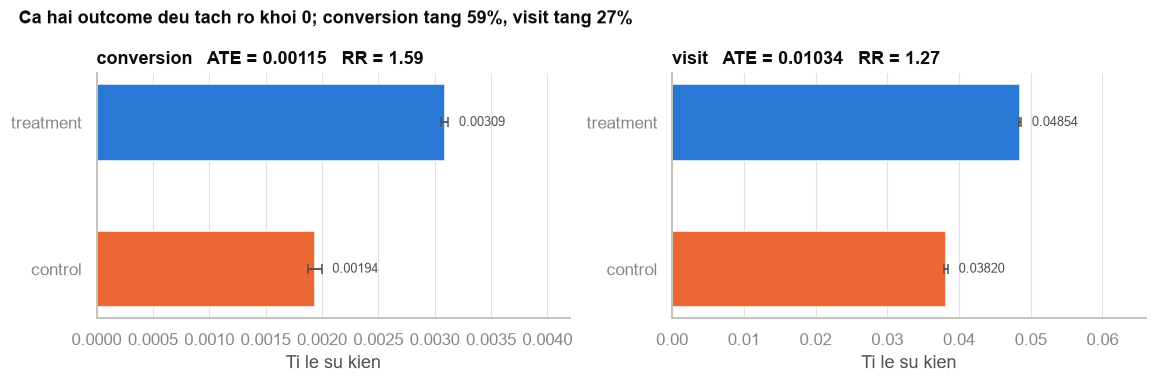

In [16]:
plot_outcomes = ["conversion", "visit"]
fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.5))
for ax, outcome in zip(axes, plot_outcomes):
    row = ate.loc[outcome]
    rates = [row["rate_control"], row["rate_treated"]]
    counts = [row["n_control"], row["n_treated"]]
    errors = [1.96 * np.sqrt(r * (1 - r) / n) for r, n in zip(rates, counts)]
    ax.barh([0, 1], rates, xerr=errors, color=[CONTROL, TREATMENT], height=0.52,
            error_kw={"ecolor": INK2, "elinewidth": 1.2, "capsize": 3.5}, zorder=2)
    for i, (rate, error) in enumerate(zip(rates, errors)):
        ax.annotate(f"{rate:.5f}", (rate + error, i), xytext=(7, 0),
                    textcoords="offset points", va="center", fontsize=8.8, color=INK2)
    ax.set_yticks([0, 1], ["control", "treatment"])
    ax.set_xlim(0, max(rates) * 1.36)
    ax.set_title(f"{outcome}   ATE = {row['difference_in_means']:.5f}   RR = {row['risk_ratio']:.2f}")
    ax.set_xlabel("Ti le su kien")
    ax.grid(axis="y", visible=False)
fig.suptitle("Ca hai outcome deu tach ro khoi 0; conversion tang 59%, visit tang 27%",
             x=0.02, ha="left", fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.show()

Tăng tuyệt đối `0,00115` nghe rất nhỏ, nhưng đó là **59,4% tương đối**, CI `[1,544; 1,647]`
cách xa `1,0`. Hiệu ứng có thật và mạnh về mặt tương đối; nó nhỏ về tuyệt đối vì nền vốn đã
là 0,19%.

Khoảng cách giữa hai cách phát biểu này là lý do mọi output value/cost trong dự án phải ghi
rõ là **kịch bản giả định**.

<a id="4.2"></a>
### 4.2 Trần thông tin: phép đo phân giải tới đâu

ATE trung bình dễ đo. Câu hỏi thật là **hiệu ứng nhỏ nhất mà 13,98 triệu dòng còn phát hiện
được**, ở `alpha = 0,05` và `power = 0,80`.

In [17]:
baseline = float(conv["rate_control"])
observed_ate = float(conv["difference_in_means"])
mde = minimum_detectable_effect(baseline, n_rows, design_propensity)

power_table = pd.DataFrame([
    {"muc tieu": label, "hieu ung": effect,
     "n can co": required_sample_size(effect, baseline, design_propensity),
     "so lan toan bo Criteo": required_sample_size(effect, baseline, design_propensity) / n_rows,
     "do duoc voi n hien tai": effect >= mde}
    for label, effect in [("ATE quan sat duoc", observed_ate),
                          ("1/2 ATE", observed_ate / 2),
                          ("1/10 ATE", observed_ate / 10),
                          ("1/100 ATE", observed_ate / 100)]
])
display(power_table.style.format({
    "hieu ung": "{:.3e}", "n can co": "{:,.0f}", "so lan toan bo Criteo": "{:.3f}"}).hide(axis="index"))

print(f"MDE voi n = {n_rows:,}      : {mde:.3e}")
print(f"ATE quan sat duoc           : {observed_ate:.3e}")
print(f"ATE / MDE                   : {observed_ate / mde:.1f} lan")

muc tieu,hieu ung,n can co,so lan toan bo Criteo,do duoc voi n hien tai
ATE quan sat duoc,1.152e-03,"89,724",0.006,True
1/2 ATE,5.759e-04,"358,895",0.026,True
1/10 ATE,1.152e-04,"8,972,381",0.642,True
1/100 ATE,1.152e-05,"897,238,085",64.182,False


MDE voi n = 13,979,592      : 9.228e-05
ATE quan sat duoc           : 1.152e-03
ATE / MDE                   : 12.5 lan


**ATE lớn gấp 12,5 lần MDE.** Câu "quảng cáo có tác dụng không" được trả lời dứt khoát, còn
thừa công suất.

Câu khó của dự án là "model A xếp hạng tốt hơn model B không", và chênh lệch giữa hai model
xếp hạng nhỏ hơn ATE vài bậc độ lớn. Bảng trên cho thấy một hiệu ứng bằng **1/100 ATE** đã
cần 64 lần toàn bộ Criteo.

Cùng dạng số học đó lặp lại ở tầng model: tách Causal Forest khỏi Response theo
`policy_area_dr` cần khoảng 2.123 lần toàn bộ dataset
([Sprint 3](../report/SPRINT_3_FINAL_REPORT.md),
[Causal Forest](../report/CAUSAL_FOREST_REPORT.md)). Trần đó nhìn thấy được ngay từ bước
phân tích dữ liệu, trước khi huấn luyện model nào.

<a id="5"></a>
## 5. Heterogeneity: có tín hiệu để mô hình hoá không, và nó có dạng gì

Trong RCT, hiệu hai tỉ lệ tính **bên trong một tầng xác định bởi biến tiền treatment** vẫn là
ước lượng không thiên lệch của CATE trung bình trong tầng đó. Không cần model, không cần giả
định thêm. Nên cả mục này là *đo*, và kết quả của nó là mốc tham chiếu để đọc mọi kết quả
CATE learner ở [notebook 02](02_modeling_and_evaluation.ipynb).

Kiểm đồng nhất bằng thống kê Cochran `Q`: dưới giả thuyết "mọi tầng có cùng hiệu ứng",
`Q ~ chi²(k−1)`. `I²` là phần phương sai vượt quá mức do sai số lấy mẫu.

<a id="5.1"></a>
### 5.1 Hiệu ứng theo phân vị của từng đặc trưng

In [18]:
y_conv = df["conversion"].to_numpy("float64")
t_arm = df["treatment"].to_numpy("float64")

strata, tests = [], []
for feature in FEATURES:
    bins = quantile_bins(df[feature].to_numpy(), 10)
    n_effective = int(pd.Series(bins).nunique(dropna=True))
    if n_effective < 2:
        tests.append({"feature": feature, "n_bins": n_effective, "phan tang duoc": False,
                      "Q": np.nan, "df": np.nan, "p": np.nan, "I2": np.nan,
                      "hieu ung nho nhat": np.nan, "hieu ung lon nhat": np.nan, "ti so": np.nan})
        continue
    table = binned_effect_table(y_conv, t_arm, bins)
    table.insert(0, "feature", feature)
    strata.append(table)
    q = cochran_q(table["effect"], table["standard_error"])
    lo, hi = float(table["effect"].min()), float(table["effect"].max())
    tests.append({"feature": feature, "n_bins": len(table), "phan tang duoc": True,
                  "Q": q["q_statistic"], "df": q["df"], "p": q["p_value"], "I2": q["i_squared"],
                  "hieu ung nho nhat": lo, "hieu ung lon nhat": hi, "ti so": hi / lo})

decile_effects = pd.concat(strata, ignore_index=True)
heterogeneity = pd.DataFrame(tests)
display(heterogeneity.style.format({
    "Q": "{:,.1f}", "df": "{:.0f}", "p": "{:.2e}", "I2": "{:.4f}",
    "hieu ung nho nhat": "{:.6f}", "hieu ung lon nhat": "{:.6f}", "ti so": "{:.1f}x"},
    na_rep="—").hide(axis="index"))

feature,n_bins,phan tang duoc,Q,df,p,I2,hieu ung nho nhat,hieu ung lon nhat,ti so
f0,8,True,837.8,7,1.30e-176,0.9916,0.000058,0.004105,70.3x
f1,1,False,—,—,—,—,—,—,—
f2,5,True,538.4,4,3.38e-115,0.9926,0.000160,0.002536,15.8x
f3,2,True,570.5,1,4.43e-126,0.9982,0.000397,0.006521,16.4x
f4,1,False,—,—,—,—,—,—,—
f5,1,False,—,—,—,—,—,—,—
f6,7,True,690.5,6,6.90e-146,0.9913,0.000145,0.006061,41.8x
f7,1,False,—,—,—,—,—,—,—
f8,5,True,780.0,4,1.65e-167,0.9949,0.000047,0.007895,169.2x
f9,3,True,663.4,2,8.79e-145,0.9970,0.000169,0.008170,48.5x


Sáu đặc trưng không phân tầng được, đúng sáu đặc trưng có `mode_share > 0,9` ở [§2.1](#2.1).
Chúng không xuất hiện tiếp trong mục này vì không có gì để đo.

Sáu đặc trưng còn lại: `p < 1e-114` ở tất cả, `I² > 0,99`, hiệu ứng giữa decile thấp nhất và
cao nhất chênh **15 đến 169 lần**.

**Có heterogeneity, và rất lớn.** Nên cách giải thích đơn giản nhất cho việc các CATE learner
không thắng được baseline — "hiệu ứng đồng nhất, không có gì để học" — bị bác bỏ.
[§5.3](#5.3) tìm ra lời giải thích thật.

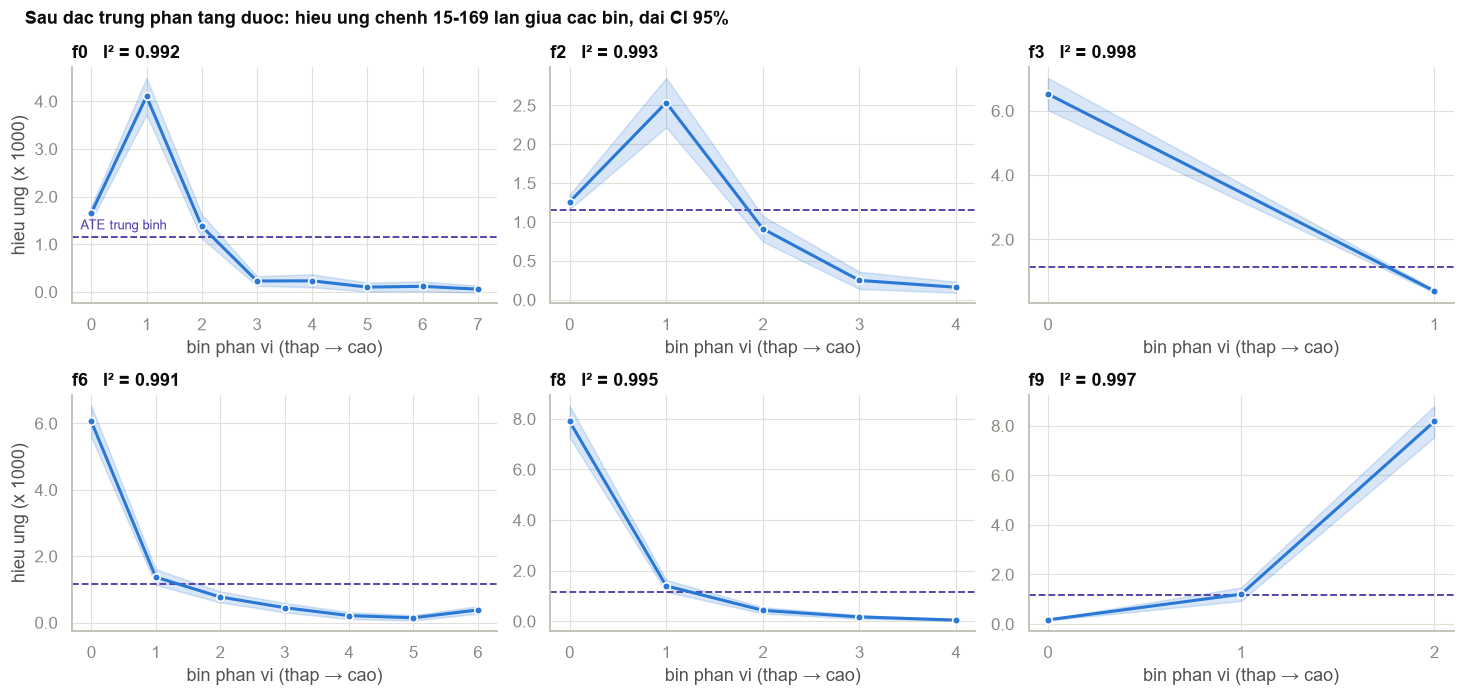

In [19]:
usable = heterogeneity.loc[heterogeneity["phan tang duoc"], "feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(13.4, 6.4), sharey=False)

for ax, feature in zip(axes.flatten(), usable):
    sub = decile_effects[decile_effects["feature"] == feature].reset_index(drop=True)
    x = np.arange(len(sub))
    ax.fill_between(x, sub["effect_ci_low"], sub["effect_ci_high"],
                    color=TREATMENT, alpha=0.18, zorder=1)
    ax.plot(x, sub["effect"], color=TREATMENT, lw=2, marker="o", ms=5,
            markeredgecolor="#fcfcfb", markeredgewidth=1.1, zorder=3)
    ax.axhline(observed_ate, color=ACCENT, ls="--", lw=1.2, zorder=2)
    ax.set_title(f"{feature}   I² = {heterogeneity.set_index('feature').loc[feature, 'I2']:.3f}")
    ax.set_xticks(x, [str(i) for i in sub["bin"]])
    ax.set_xlabel("bin phan vi (thap → cao)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v * 1000:.1f}"))

axes[0, 0].set_ylabel("hieu ung (x 1000)")
axes[1, 0].set_ylabel("hieu ung (x 1000)")
axes[0, 0].annotate("ATE trung binh", (0.02, observed_ate), xycoords=("axes fraction", "data"),
                    xytext=(0, 5), textcoords="offset points", fontsize=8.2, color=ACCENT)
fig.suptitle("Sau dac trung phan tang duoc: hieu ung chenh 15-169 lan giua cac bin, dai CI 95%",
             x=0.02, ha="left", fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.show()

<a id="5.2"></a>
### 5.2 Hiệu ứng theo pattern sentinel

[§2.3](#2.3) cho thấy 53 pattern "quan sát được / không quan sát được" là cấu trúc chi phối
dữ liệu. Bản thân pattern đó có phải một moderator không.

In [20]:
_, sentinel_values = sentinel_mask_matrix(df, FEATURES)
pattern_key = np.zeros(n_rows, dtype="int64")
for i, feature in enumerate(FEATURES):
    pattern_key |= ((df[feature].to_numpy() == sentinel_values[feature]).astype("int64") << i)

pattern_effects = binned_effect_table(y_conv, t_arm, pattern_key, bin_label="pattern_key")
pattern_effects = pattern_effects[pattern_effects["n"] >= 20_000].reset_index(drop=True)
pattern_effects["pattern"] = [
    "".join("." if b == "1" else "O" for b in format(int(k), "012b")[::-1])
    for k in pattern_effects["pattern_key"]
]

q_pattern = cochran_q(pattern_effects["effect"], pattern_effects["standard_error"])
top = pattern_effects.sort_values("effect", ascending=False).head(10)
display(top[["pattern", "n", "events_control", "baseline_rate", "effect",
             "effect_ci_low", "effect_ci_high", "risk_ratio"]]
        .style.format({"n": "{:,.0f}", "events_control": "{:,.0f}", "baseline_rate": "{:.6f}",
                       "effect": "{:.6f}", "effect_ci_low": "{:.6f}",
                       "effect_ci_high": "{:.6f}", "risk_ratio": "{:.3f}"}).hide(axis="index"))

worst = pattern_effects.loc[pattern_effects["effect"].idxmin()]
best = pattern_effects.loc[pattern_effects["effect"].idxmax()]
separated = pattern_effects[pattern_effects["effect_ci_low"] > 0]

print(f"So pattern >= 20.000 dong : {len(pattern_effects)} "
      f"(phu {pattern_effects['n'].sum() / n_rows:.3f} du lieu)")
print(f"Thap nhat : {worst['effect']:+.6f}  CI [{worst['effect_ci_low']:+.6f}; "
      f"{worst['effect_ci_high']:+.6f}]  n = {worst['n']:,.0f}")
print(f"Cao nhat  : {best['effect']:+.6f}  CI [{best['effect_ci_low']:+.6f}; "
      f"{best['effect_ci_high']:+.6f}]  n = {best['n']:,.0f}")
print(f"So pattern co CI 95% hoan toan tren 0: {len(separated)}/{len(pattern_effects)}")
print(f"Ti so giua pattern tach khoi 0 manh nhat va yeu nhat: "
      f"{separated['effect'].max() / separated['effect'].min():,.0f}x")
print(f"Cochran Q = {q_pattern['q_statistic']:,.1f}, df = {q_pattern['df']}, "
      f"p = {q_pattern['p_value']:.2e}, I² = {q_pattern['i_squared']:.4f}")

pattern,n,events_control,baseline_rate,effect,effect_ci_low,effect_ci_high,risk_ratio
OOOOOOOOOOOO,"22,392",489,0.165259,0.038930,0.024397,0.053463,1.236
O.OOOOOOOOO.,"23,716",90,0.031293,0.037708,0.030474,0.044943,2.205
O.OOO.O.OOOO,"76,994",844,0.079578,0.033816,0.028129,0.039504,1.425
O.OOO.O.OOO.,"68,111",230,0.025641,0.016665,0.013013,0.020316,1.650
..O.O...OOOO,"61,625",414,0.044132,0.011032,0.006438,0.015627,1.250
O.O.O.O.OOO.,"48,403",120,0.016611,0.008717,0.005402,0.012032,1.525
O.OO.OOOOO..,"75,677",34,0.003977,0.007762,0.006198,0.009325,2.952
OOOO.OOOOO..,"86,980",56,0.005591,0.004712,0.003087,0.006338,1.843
O.OOO.O.O.O.,"31,616",34,0.007487,0.004553,0.001729,0.007377,1.608
O.OO..O.OO..,"605,518",268,0.003233,0.003244,0.002800,0.003687,2.003


So pattern >= 20.000 dong : 26 (phu 0.990 du lieu)
Thap nhat : -0.000133  CI [-0.000379; +0.000113]  n = 168,096
Cao nhat  : +0.038930  CI [+0.024397; +0.053463]  n = 22,392
So pattern co CI 95% hoan toan tren 0: 17/26
Ti so giua pattern tach khoi 0 manh nhat va yeu nhat: 1,203x
Cochran Q = 861.2, df = 25, p = 1.47e-165, I² = 0.9710


Trong nhóm pattern có CI 95% tách hẳn khỏi 0, hiệu ứng chênh nhau khoảng **ba bậc độ lớn**.
*Cấu hình cái gì quan sát được* là moderator mạnh nhất tìm thấy trong dữ liệu, mạnh hơn giá
trị của bất kỳ đặc trưng nào.

Một pattern có ước lượng điểm âm. CI của nó chứa 0, tức dao động lấy mẫu trên một nhóm ít
conversion. **Không đọc thành "quảng cáo gây hại"** — cùng quy tắc đã dùng cho score âm ở các
sprint: giá trị âm là nhiễu ước lượng hoặc dự đoán phụ thuộc model, không phải một principal
stratum quan sát được.

Đây là loại cấu trúc model dạng cây bắt được tự động, và là một lý do cụ thể vì sao
[dự án không tạo feature phái sinh](../README.md): thông tin nằm ở ngưỡng và tương tác, đúng
thứ LightGBM tự dựng.

<a id="5.3"></a>
### 5.3 Hiệu ứng có dạng gì

Heterogeneity rất lớn. Còn lại câu quan trọng hơn: nó **có dạng gì**. Hai khả năng, hai kết
luận vận hành trái ngược:

| Dạng | Công thức | Hệ quả |
|---|---|---|
| Hiệu ứng độc lập với rủi ro nền | `τ(x)` không liên quan `p₀(x)` | Phải ước lượng CATE mới xếp hạng đúng |
| Hiệu ứng tỉ lệ với rủi ro nền | `τ(x) ≈ (RR − 1) · p₀(x)`, `RR` gần hằng | Xếp theo `p₀(x)` **là** xếp theo `τ(x)` |

Ở khả năng thứ hai, một model dự báo outcome xếp hạng đúng vì thứ tự nó tạo ra trùng với thứ
tự cần tìm, dù nó không hề ước lượng hiệu ứng.

Phép đo có sẵn: 30 tầng phân vị ở [§5.1](#5.1), mỗi tầng có cả `baseline_rate` lẫn
`effect`. Các tầng của **những feature khác nhau chồng lấn customer**, nên bảng gộp chỉ
dùng để mô tả correlation. Cochran Q/I² được tính trong từng feature hoặc trên 26 sentinel
pattern rời nhau.

In [21]:
dominance = prognostic_dominance_summary(decile_effects, independent_strata=False)
pattern_dominance = prognostic_dominance_summary(pattern_effects)
feature_dominance = {
    feature: prognostic_dominance_summary(group)
    for feature, group in decile_effects.groupby("feature")
    if len(group) >= 3
}

evidence = pd.DataFrame({
    "30 tang chong lan (mo ta)": dominance,
    "26 pattern roi nhau": pattern_dominance,
}).loc[["n_strata", "pearson_r", "spearman_rho", "pooled_risk_ratio",
        "effect_over_baseline_median", "q_additive", "q_multiplicative",
        "q_ratio_additive_over_multiplicative", "i_squared_additive",
        "i_squared_multiplicative"]]
display(evidence.style.format(precision=4, na_rep="—"))
display(pd.DataFrame(feature_dominance).T[["n_strata", "pearson_r", "spearman_rho",
    "q_ratio_additive_over_multiplicative"]].style.format(precision=4))

,30 tang chong lan (mo ta),26 pattern roi nhau
n_strata,30,26
pearson_r,0.9838,0.7686
spearman_rho,0.9591,0.8831
pooled_risk_ratio,—,1.4176
effect_over_baseline_median,0.5329,0.4749
q_additive,—,861.1714
q_multiplicative,—,150.1543
q_ratio_additive_over_multiplicative,—,5.7352
i_squared_additive,—,0.9710
i_squared_multiplicative,—,0.8335


,n_strata,pearson_r,spearman_rho,q_ratio_additive_over_multiplicative
f0,8,0.9948,0.9762,36.3084
f2,5,0.9912,1.0000,98.0063
f6,7,0.9967,0.8929,13.5872
f8,5,0.9996,1.0000,211.5844
f9,3,1.0000,1.0000,129.6560


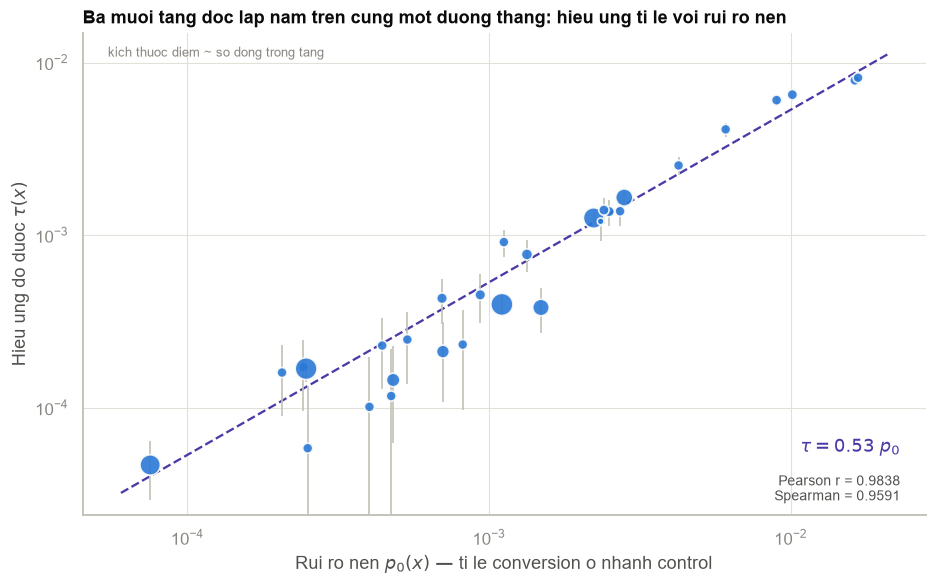

In [22]:
fig, ax = plt.subplots(figsize=(8.6, 5.4))

slope = dominance["effect_over_baseline_median"]
grid = np.array([decile_effects["baseline_rate"].min() * 0.8,
                 decile_effects["baseline_rate"].max() * 1.25])
ax.plot(grid, slope * grid, color=ACCENT, ls="--", lw=1.5, zorder=1)

sizes = 20 + 190 * (np.log10(decile_effects["n"]) - np.log10(decile_effects["n"].min())) / \
        (np.log10(decile_effects["n"].max()) - np.log10(decile_effects["n"].min()) + 1e-9)
ax.errorbar(decile_effects["baseline_rate"], decile_effects["effect"],
            yerr=[decile_effects["effect"] - decile_effects["effect_ci_low"],
                  decile_effects["effect_ci_high"] - decile_effects["effect"]],
            fmt="none", ecolor=REF, elinewidth=1.1, zorder=2)
ax.scatter(decile_effects["baseline_rate"], decile_effects["effect"], s=sizes,
           color=TREATMENT, alpha=0.9, zorder=3, edgecolor="#fcfcfb", linewidth=1.1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rui ro nen $p_0(x)$ — ti le conversion o nhanh control")
ax.set_ylabel(r"Hieu ung do duoc $\tau(x)$")
ax.set_title("Ba muoi tang doc lap nam tren cung mot duong thang: hieu ung ti le voi rui ro nen")
ax.annotate(f"$\\tau = {slope:.2f}\\; p_0$", (0.97, 0.13), xycoords="axes fraction",
            ha="right", fontsize=12, color=ACCENT)
ax.annotate(f"Pearson r = {dominance['pearson_r']:.4f}\n"
            f"Spearman = {dominance['spearman_rho']:.4f}",
            (0.97, 0.03), xycoords="axes fraction", ha="right", fontsize=9, color=INK2)
ax.annotate("kich thuoc diem ~ so dong trong tang", (0.03, 0.95), xycoords="axes fraction",
            fontsize=8.2, color=MUTED)
plt.tight_layout()
plt.show()

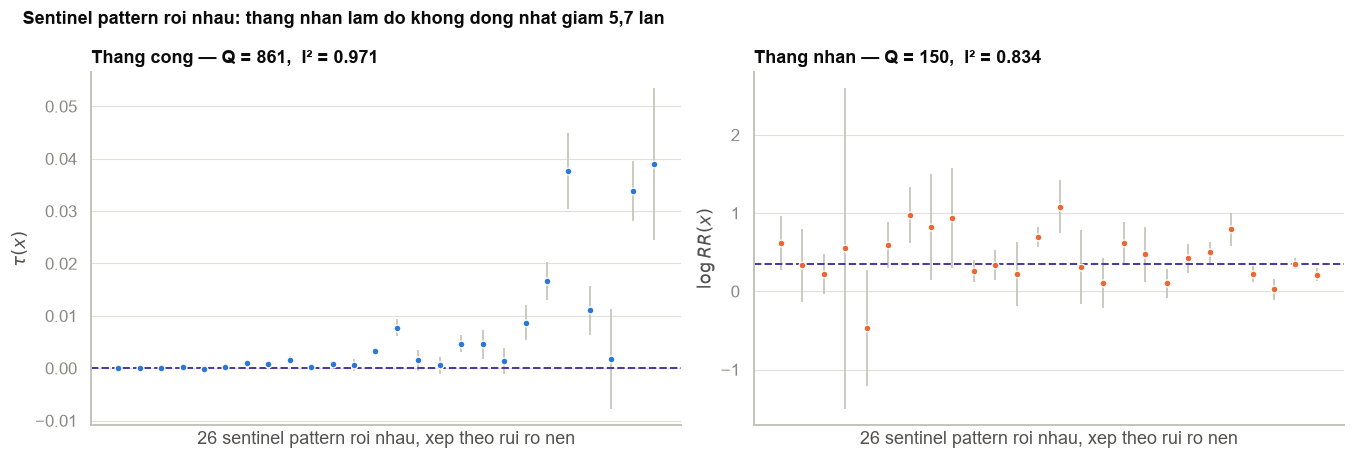

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2), sharex=True)
sub = pattern_effects.sort_values("baseline_rate").reset_index(drop=True)
x = np.arange(len(sub))
z = 1.96

pooled_effect = cochran_q(sub["effect"], sub["standard_error"])["pooled_estimate"]
axes[0].errorbar(x, sub["effect"], yerr=z * sub["standard_error"], fmt="o", ms=4.5,
                 color=TREATMENT, ecolor=REF, elinewidth=1.1, markeredgecolor="#fcfcfb",
                 markeredgewidth=0.9)
axes[0].axhline(pooled_effect, color=ACCENT, ls="--", lw=1.3)
axes[0].set_ylabel(r"$\tau(x)$")
axes[0].set_title(f"Thang cong — Q = {pattern_dominance['q_additive']:,.0f},  I² = {pattern_dominance['i_squared_additive']:.3f}")

pooled_rr = np.log(pattern_dominance["pooled_risk_ratio"])
axes[1].errorbar(x, sub["log_risk_ratio"], yerr=z * sub["se_log_risk_ratio"], fmt="o", ms=4.5,
                 color=CONTROL, ecolor=REF, elinewidth=1.1, markeredgecolor="#fcfcfb",
                 markeredgewidth=0.9)
axes[1].axhline(pooled_rr, color=ACCENT, ls="--", lw=1.3)
axes[1].set_ylabel(r"$\log RR(x)$")
axes[1].set_title(f"Thang nhan — Q = {pattern_dominance['q_multiplicative']:,.0f},  I² = {pattern_dominance['i_squared_multiplicative']:.3f}")

for ax in axes:
    ax.set_xlabel("26 sentinel pattern roi nhau, xep theo rui ro nen")
    ax.set_xticks([])
fig.suptitle("Sentinel pattern roi nhau: thang nhan lam do khong dong nhat giam 5,7 lan",
             x=0.02, ha="left", fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.show()

Ba lát cắt bằng chứng, cùng một kết luận nhưng khác phạm vi suy luận.

1. **Tương quan mô tả.** Trên 30 tầng chồng lấn, `corr(p₀, τ)` bằng **0,984** (Pearson)
   và **0,959** (Spearman). Không dùng p-value hay Cochran Q gộp vì cùng customer xuất hiện
   trong partition của nhiều feature.
2. **Tính ổn định theo feature.** Trong năm feature có ít nhất ba strata, Pearson nằm trong
   `[0,991; 1,000]`; trung vị mô tả gộp `τ/p₀` là **0,53**.
3. **Kiểm định trên strata rời nhau.** Với 26 sentinel pattern, `Q` thang cộng **861**,
   thang nhân **150** — giảm **5,7 lần**; Pearson `0,769`, Spearman `0,883`.

Tức `τ(x) ≈ 0,53 · p₀(x)` giải thích gần hết heterogeneity của bộ dữ liệu. `p₀` đơn điệu
tăng, nên **xếp hạng theo `p₀` cho gần đúng thứ tự xếp hạng theo `τ`**.

Trên sentinel pattern, cả hai thang vẫn bác bỏ đồng nhất tuyệt đối, nên vẫn còn dư địa
lý thuyết cho một estimator tốt hơn. Dư địa đó nằm dưới ngưỡng phân giải tính ở [§4.2](#4.2).

<a id="5.4"></a>
### 5.4 Điều này dự đoán trước kết quả của ba sprint

[§5.3](#5.3) cho một dự đoán kiểm chứng được: **một model dự báo `P(conversion)` sẽ xếp hạng
khách hàng ngang hoặc hơn các CATE learner**, vì nó ước lượng đúng `p₀` — đại lượng mà thứ tự
cần tìm phụ thuộc vào — và ước lượng với variance thấp hơn nhiều.

Ba sprint sau đó xác nhận:

| Vòng | Kết quả |
|---|---|
| Sprint 1 | 5 model trên cùng holdout; không phương pháp nhân quả nào tách được khỏi Response baseline |
| Sprint 3 | 12 candidate qua protocol đăng ký trước; `0/12` đạt promotion rule |
| Causal Forest | `policy_area_dr` hạng 1/6 nhưng CI của chênh lệch chứa 0 trên **cả hai** metric — hoà |

Chế độ này đã được mô tả trong tài liệu:

- **Fernández-Loría & Provost, JMLR 2022** — *causal bias–variance tradeoff*: dự báo outcome
  có bias nhưng variance nhỏ hơn nhiều; khi variance của ước lượng CATE đủ lớn, nó ra ít
  quyết định sai hơn.
- **Fernández-Loría & Loría, arXiv 2206.12532** — proxy xếp hạng đúng khi nó phản ánh
  dominant moderator. Điều kiện đủ được hiện thực ở [`src/proxy_diagnostic.py`](../src/proxy_diagnostic.py).
- **Diemert et al., AdKDD 2018** — chính nhóm tạo dataset khuyến nghị dùng `visit` thay
  `conversion` vì tín hiệu uplift của `conversion` quá yếu.

Rà soát đầy đủ: [research landscape](../planning/RESEARCH_LANDSCAPE_2026.md).

**Phạm vi.** `τ ≈ 0,53 · p₀` là mô tả trên các tầng biên, chưa kiểm chứng ở mức cá nhân. Chẩn
đoán điều kiện đủ trong [`src/proxy_diagnostic.py`](../src/proxy_diagnostic.py) **không đạt**
ở mọi mức `beta_max` đã thử, nên lý thuyết không bảo đảm Response xếp hạng đúng dù thực
nghiệm nó thắng. Không mâu thuẫn: đó là điều kiện đủ, không phải điều kiện cần.

<a id="6"></a>
## 6. Chiến lược mẫu và phân tách

### 6.1 Mẫu 5% có đại diện được không

Biểu đồ phân phối và bảng SMD ở trên chạy trên mẫu stratified 5%. Bảng dưới đo sai lệch do
lấy mẫu.

In [24]:
representativity = sample_representativity(
    df, sample_5pct, FEATURES + ["treatment", "conversion", "visit", "exposure"])
display(representativity.style.format({
    "full_mean": "{:.6f}", "sample_mean": "{:.6f}",
    "difference": "{:+.2e}", "smd": "{:+.5f}"}).hide(axis="index"))
print(f"|SMD| lon nhat do lay mau: {representativity['smd'].abs().max():.5f}")
print(f"Cỡ mau: {len(sample_5pct):,} dong")

column,full_mean,sample_mean,difference,smd
f0,19.620296,19.620092,-2.04e-04,-0.00004
f1,10.069978,10.069993,+1.53e-05,+0.00015
f2,8.446583,8.446284,-2.99e-04,-0.00100
f3,4.178923,4.181073,+2.15e-03,+0.00161
f4,10.338838,10.338331,-5.06e-04,-0.00148
f5,4.028512,4.028367,-1.46e-04,-0.00034
f6,-4.155355,-4.150029,+5.33e-03,+0.00116
f7,5.101766,5.101637,-1.28e-04,-0.00011
f8,3.933581,3.933695,+1.14e-04,+0.00201
f9,16.027639,16.018991,-8.65e-03,-0.00123


|SMD| lon nhat do lay mau: 0.00201
Cỡ mau: 698,980 dong


### 6.2 Thiết kế phân tách dùng cho các sprint

Notebook không tự chia dữ liệu; nó ghi lại thiết kế các sprint đã dùng, để nối sang
[notebook 02](02_modeling_and_evaluation.ipynb):

| Tập | Tỉ lệ trong mẫu 50% | Quy về toàn bộ | Dùng để |
|---|---:|---:|---|
| Fit | 56% | ~28% | Huấn luyện |
| Validation | 14% | ~7% | Chọn siêu tham số |
| Test | 30% | 15% — 2.096.940 dòng | Chấm điểm cuối, **đúng một lần** |

Hai cơ chế bảo vệ, cả hai đều kiểm chứng được:

- **Chốt cấu hình trước khi mở test.** Cấu hình release ghi vào
  [`configs/sprint1_release_5models.json`](../configs/sprint1_release_5models.json) dựa trên
  validation, rồi mới chạy test.
- **Băm chỉ số hàng.** SHA-256 của chỉ số mỗi tập ghi vào manifest, nên khẳng định được hai
  lần chạy cách nhau nhiều tuần dùng đúng cùng một tập test.

Stratify theo `treatment × conversion` để mỗi tập giữ tỉ lệ 85/15 và đủ sự kiện hiếm: với
4.063 conversion ở control, một phép chia không stratify có thể cho tập test nghèo sự kiện
tới mức Qini trả `NaN`.

<a id="7"></a>
## 7. Tổng hợp

In [25]:
final = pd.read_csv(EDA_DIR / "eda_summary.csv")
display(final.style.format({"value": lambda v: f"{v:,.6g}"}).hide(axis="index"))
print(f"Tong thoi gian notebook: {time.time() - t0:.0f}s")

metric,value
n_rows,1.39796e+07
n_columns,16
n_missing_cells,0
treatment_rate,0.85
conversion_rate,0.00291668
conversion_events_control,"4,063"
ate_conversion,0.00115187
ate_conversion_ci_low,0.00108451
ate_conversion_ci_high,0.00121924
risk_ratio_conversion,1.59449


Tong thoi gian notebook: 139s


## Kết luận

**Dữ liệu và cấu trúc**

1. File khớp SHA-256 đã đăng ký; 13.979.592 dòng × 16 cột, 0 ô thiếu, contract pass.
2. "0 ô thiếu" chỉ đúng về cú pháp. Sáu trên mười hai đặc trưng có hơn 90% khối lượng ở một
   giá trị duy nhất; bốn cặp có mask sentinel **trùng khít tuyệt đối**, gợi ý một cơ chế
   mã hóa dùng chung nhưng không chứng minh đây là missingness.
3. Trung vị số đặc trưng quan sát được trên mỗi dòng là **2 trên 12**; chỉ có 53 pattern
   sentinel trên 4.096 khả năng.
4. `(f4, f10)` và `(f5, f7)` có `|Spearman| = 0,999` trong khi `|Pearson|` chỉ `0,66`–`0,75`
   — gần trùng khít về thứ hạng, và chỉ Spearman phát hiện được.
5. 15,2% số dòng có vector đặc trưng trùng với một dòng khác.

**Thiết kế**

6. `|SMD|` lớn nhất là `0,049`, dưới ngưỡng quy ước `0,1`. Propensity AUC `0,507` (logistic)
   và `0,506` (gradient boosting): model phi tuyến cũng không phân biệt được hai nhánh.
   Positivity giữ tuyệt đối vì propensity là hằng số thiết kế.
7. Các chẩn đoán này **không chứng minh** randomization; căn cứ đến từ provenance.
8. `exposure` có đúng 0 sự kiện ở nhánh control; `P(conversion = 1 | visit = 0) = 0` chính
   xác. Cả hai là biến hậu can thiệp và bị cấm làm feature. `visit` làm **outcome** thì hợp lệ.

**Hiệu ứng và giới hạn đo lường**

9. ATE conversion `0,001152`, CI `[0,001085; 0,001219]`; risk ratio `1,594`, CI
   `[1,544; 1,647]`.
10. Control chỉ có **4.063 conversion**. MDE `9,23e-05`; ATE lớn gấp 12,5 lần MDE, nhưng một
    hiệu ứng bằng 1/100 ATE đã cần 64 lần toàn bộ Criteo.

**Heterogeneity**

11. Heterogeneity tồn tại và rất lớn: sáu đặc trưng phân tầng được đều có `I² > 0,99`, hiệu
    ứng chênh 15–169 lần giữa các bin, và chênh ba bậc độ lớn giữa các pattern sentinel.
12. Nhưng hiệu ứng gần như **tỉ lệ thuận với rủi ro nền**: correlation mô tả gộp là `0,984`,
    Pearson theo từng feature là `0,991–1,000`; trên 26 pattern rời nhau, `Q` giảm 5,7 lần
    khi chuyển từ thang cộng sang thang nhân.
13. Nên xếp hạng theo `p₀` cho gần đúng thứ tự xếp hạng theo `τ`. Từ dữ liệu thô, trước mọi
    model, điều này đã dự đoán trước kết quả mà ba sprint sau đó xác nhận.

## Giới hạn

- Cân bằng quan sát được không chứng minh cơ chế gán; cần provenance upstream.
- Giả thuyết sentinel value là suy luận từ cấu trúc, không được data card xác nhận. Không
  dùng nó để hoàn nguyên giá trị gốc.
- `τ ≈ 0,53 · p₀` là mô tả trên các tầng biên, không phải mệnh đề ở mức cá nhân. Điều kiện đủ
  của [`src/proxy_diagnostic.py`](../src/proxy_diagnostic.py) không đạt ở mọi mức `beta_max`
  đã thử.
- Đặc trưng đã ẩn danh và chiếu ngẫu nhiên, nên mọi phát hiện về cấu trúc là về *hình dạng
  phân phối*, không phải về ý nghĩa kinh doanh.
- Bootstrap của dự án lấy mẫu ở mức dòng trong khi 15,2% dòng có vector đặc trưng trùng lặp.

**Tiếp theo:** [`02_modeling_and_evaluation.ipynb`](02_modeling_and_evaluation.ipynb) — cùng
dữ liệu, câu hỏi khác: model nào xếp hạng tốt hơn, và chênh lệch có tách khỏi 0 không.